In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.morphology import thin
from skimage.morphology import medial_axis
import matplotlib.patches as mpatches

In [3]:
def order_board_corners(detected_corners, detected_ids, corner_marker_id=18):
    """
    From all detected ArUco markers, find the 4 board corner markers (ID=18)
    and return their outer corners in order: [TL, TR, BR, BL].

    Parameters
    ----------
    detected_corners : list   - corners returned by cv2.aruco.detectMarkers()
    detected_ids     : array  - IDs returned by cv2.aruco.detectMarkers()
    corner_marker_id : int    - the ArUco ID used for board corners (default 18)

    Returns
    -------
    board_pts : np.array of shape (4, 2) - ordered [TL, TR, BR, BL] outer corners
    """

    if detected_ids is None:
        raise ValueError("No ArUco markers detected in the image.")

    # ── Collect all markers with ID == 18 ─────────────────────────────────────
    corner_markers = []
    for i, marker_id in enumerate(detected_ids.flatten()):
        if marker_id == corner_marker_id:
            # corners[i] has shape (1, 4, 2) → squeeze to (4, 2)
            pts = detected_corners[i].reshape(4, 2)
            center = pts.mean(axis=0)  # center of this marker
            corner_markers.append({'center': center, 'corners': pts})

    if len(corner_markers) != 4:
        raise ValueError(f"Expected 4 corner markers (ID={corner_marker_id}), "f"found {len(corner_markers)}.")

    # ── Sort markers by spatial position ──────────────────────────────────────
    # Using center points for classification
    centers = np.array([m['center'] for m in corner_markers])

    # Sum x+y → smallest = TL, largest = BR
    sums = centers[:, 0] + centers[:, 1]
    # Diff x-y → smallest = BL, largest = TR
    diffs = centers[:, 0] - centers[:, 1]

    tl_idx = np.argmin(sums)
    br_idx = np.argmax(sums)
    tr_idx = np.argmax(diffs)
    bl_idx = np.argmin(diffs)

    ordered = [
        corner_markers[tl_idx],
        corner_markers[tr_idx],
        corner_markers[br_idx],
        corner_markers[bl_idx],
    ]

    # ── Pick the correct outer corner from each marker ─────────────────────────
    # corners layout per marker: [0]=TL, [1]=TR, [2]=BR, [3]=BL
    outer_pts = np.array([
        ordered[0]['corners'][0],  # TL marker → its top-left corner
        ordered[1]['corners'][1],  # TR marker → its top-right corner
        ordered[2]['corners'][2],  # BR marker → its bottom-right corner
        ordered[3]['corners'][3],  # BL marker → its bottom-left corner
    ], dtype=np.float32)

    return outer_pts


def warp_board(image, board_pts, output_size=(835, 588)):
    """
    Apply perspective transform to get a top-down view of the whiteboard.

    Parameters
    ----------
    image       : np.array  - input image (BGR)
    board_pts   : np.array  - 4 outer corner points [TL, TR, BR, BL]
    output_size : tuple     - (width, height) of the warped output image

    Returns
    -------
    warped : np.array - perspective-corrected top-down image
    M      : np.array - the 3x3 homography matrix (useful for mapping
                        coordinates back later)
    """

    w, h = output_size

    # ── Destination points (perfect rectangle) ────────────────────────────────
    dst_pts = np.array([
        [0,     0    ],  # TL
        [w - 1, 0    ],  # TR
        [w - 1, h - 1],  # BR
        [0,     h - 1],  # BL
    ], dtype=np.float32)

    # ── Compute homography & warp ─────────────────────────────────────────────
    M = cv2.getPerspectiveTransform(board_pts, dst_pts)
    warped = cv2.warpPerspective(image, M, (w, h))

    return warped, M


def detect_and_warp(image_path, output_size=(835, 588), show=True):
    """
    Full pipeline: load image → detect markers → warp to top-down view.

    Parameters
    ----------
    image_path  : str   - path to the input image
    output_size : tuple - (width, height) of output
    show        : bool  - display original and warped images side by side
    """

    # ── Load image ────────────────────────────────────────────────────────────
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # ── Detect all ArUco markers ──────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(image)

    # ── Get ordered board corners ─────────────────────────────────────────────
    board_pts = order_board_corners(detected_corners, detected_ids, corner_marker_id=18)

    # ── Warp ──────────────────────────────────────────────────────────────────
    warped, M = warp_board(image, board_pts, output_size=output_size)

    # ── Display ───────────────────────────────────────────────────────────────
    if show:
        # Draw detected markers on original for debugging
        debug_img = image.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)

        # Draw the 4 outer registration points
        for pt in board_pts.astype(int):
            cv2.circle(debug_img, tuple(pt), 8, (0, 255, 0), -1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original — detected corners marked', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Warped — top-down view', fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"  Board corners (outer pts):")
    labels = ['TL', 'TR', 'BR', 'BL']
    for label, pt in zip(labels, board_pts):
        print(f"    {label}: ({pt[0]:.1f}, {pt[1]:.1f})")
    print(f"  Homography matrix M:\n{M}")

    return warped, M

In [4]:
def correct_image_orientation(image, corner_marker_id=18, show=True):
    """
    Detects the first visible corner marker (ID=18) and uses its orientation
    to rotate the entire image to the correct upright position.

    Parameters
    ----------
    image            : np.array - input image (BGR)
    corner_marker_id : int      - ArUco ID used for board corners (default 18)
    show             : bool     - display before/after images

    Returns
    -------
    corrected : np.array - rotation-corrected image
    rotation  : int      - degrees rotated (0, 90, 180, 270)
    """

    # ── Detect markers ─────────────────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(image)

    if detected_ids is None:
        raise ValueError("No ArUco markers detected in the image.")

    # ── Find the first ID=18 marker ────────────────────────────────────────────
    target_index = None
    for i, marker_id in enumerate(detected_ids.flatten()):
        if marker_id == corner_marker_id:
            target_index = i
            break

    if target_index is None:
        raise ValueError(f"No marker with ID={corner_marker_id} found in image.")

    # ── Get corner[0] position relative to marker center ──────────────────────
    pts    = detected_corners[target_index].reshape(4, 2)
    center = pts.mean(axis=0)
    c0     = pts[0]  # canonical top-left corner of the marker

    # Vector from center to corner[0]
    dx = c0[0] - center[0]  # positive → right, negative → left
    dy = c0[1] - center[1]  # positive → down,  negative → up

    # ── Determine rotation ─────────────────────────────────────────────────────
    # corner[0] should be at top-left (dx < 0, dy < 0) when upright
    if dx < 0 and dy < 0:
        rotation = 0          # already upright
    elif dx > 0 and dy < 0:
        rotation = 90         # rotated 90° CW → correct with 90° CCW
    elif dx > 0 and dy > 0:
        rotation = 180        # upside down → correct with 180°
    else:                     # dx < 0 and dy > 0
        rotation = 270        # rotated 90° CCW → correct with 90° CW

    # ── Apply rotation ─────────────────────────────────────────────────────────
    if rotation == 0:
        corrected = image.copy()
    elif rotation == 90:
        corrected = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif rotation == 180:
        corrected = cv2.rotate(image, cv2.ROTATE_180)
    elif rotation == 270:
        corrected = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Mark corner[0] and center on original for debugging
        debug_img = image.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)
        cv2.circle(debug_img, tuple(c0.astype(int)),    10, (0, 255, 0), -1)  # green = corner[0]
        cv2.circle(debug_img, tuple(center.astype(int)), 8, (0, 0, 255), -1)  # blue  = center

        axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Original — corner[0] detected, rotation needed: {rotation}°', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Corrected — rotated {rotation}°', fontsize=11)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"  First ID={corner_marker_id} marker found at index: {target_index}")
    print(f"  corner[0] position : ({c0[0]:.1f}, {c0[1]:.1f})")
    print(f"  Marker center      : ({center[0]:.1f}, {center[1]:.1f})")
    print(f"  dx={dx:.1f}, dy={dy:.1f}")
    print(f"  Rotation applied   : {rotation}°")

    return corrected, rotation

In [5]:
def process_board_image(image_path, output_size=(835, 588), corner_marker_id=18, show=True):
    """
    Full pipeline:
        1. Load image
        2. Correct orientation using first detected ID=18 marker
        3. Detect all 4 corner markers on the corrected image
        4. Warp to top-down view
        5. Erase corner markers with white boxes
    """

    # ── Step 1: Load ───────────────────────────────────────────────────────────
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    print("── Step 1: Image loaded ──────────────────────────────────────────")
    print(f"  Original size : {image.shape[1]}w x {image.shape[0]}h px")

    # ── Step 2: Correct orientation ────────────────────────────────────────────
    # Note: This assumes correct_image_orientation is defined in your environment
    print("\n── Step 2: Correcting orientation ────────────────────────────────")
    corrected, rotation = correct_image_orientation(image, 
                                                    corner_marker_id=corner_marker_id, 
                                                    show=False)
    print(f"  Rotation applied : {rotation}°")
    print(f"  Corrected size   : {corrected.shape[1]}w x {corrected.shape[0]}h px")

    # ── Step 3: Detect markers on corrected image ──────────────────────────────
    print("\n── Step 3: Detecting corner markers ──────────────────────────────")
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(corrected)

    # Note: This assumes order_board_corners is defined in your environment
    board_pts = order_board_corners(detected_corners, detected_ids, 
                                    corner_marker_id=corner_marker_id)

    labels = ['TL', 'TR', 'BR', 'BL']
    for label, pt in zip(labels, board_pts):
        print(f"  {label}: ({pt[0]:.1f}, {pt[1]:.1f})")

    # ── Step 4: Warp ───────────────────────────────────────────────────────────
    print("\n── Step 4: Warping to top-down view ──────────────────────────────")
    # Note: This assumes warp_board is defined in your environment
    warped, M = warp_board(corrected, board_pts, output_size=output_size)
    print(f"  Output size : {warped.shape[1]}w x {warped.shape[0]}h px")

    # ── Step 5: Erase Markers ──────────────────────────────────────────────────
    print("\n── Step 5: Erasing ArUco markers ──────────────────────────────────")
    out_w, out_h = output_size
    
    # We define a box size relative to the board dimensions (approx 7% of width)
    # to ensure the marker is fully covered.
    box_w = int(out_w * 0.07)
    box_h = int(out_h * 0.10)

    # Coordinates for the 4 corners: [x1, y1, x2, y2]
    rects = [
        (0, 0, box_w, box_h),                     # Top-Left
        (out_w - box_w, 0, out_w, box_h),         # Top-Right
        (out_w - box_w, out_h - box_h, out_w, out_h), # Bottom-Right
        (0, out_h - box_h, box_w, out_h)          # Bottom-Left
    ]

    for (x1, y1, x2, y2) in rects:
        cv2.rectangle(warped, (x1, y1), (x2, y2), (255, 255, 255), -1)
    
    print("  Markers successfully whited out.")

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        # Draw markers and registration points on corrected image for debug
        debug_img = corrected.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)
        for pt in board_pts.astype(int):
            cv2.circle(debug_img, tuple(pt), 8, (0, 255, 0), -1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'1. Original ({image.shape[1]}x{image.shape[0]})', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'2. Detection & Orientation ({rotation}°)', fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f'3. Warped & Erased ({out_w}x{out_h})', fontsize=11)
        axes[2].axis('off')

        plt.suptitle('Board Processing Pipeline with Marker Erasure', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    return warped, M, rotation

In [6]:
def and_gate():
    """
    Returns the configuration for the AND gate.

    Returns
    -------
    dict with:
        'id'     : int  - ArUco marker ID for this gate
        'name'   : str  - gate name
        'left'   : int  - bounding box offset from center to left edge   (px)
        'right'  : int  - bounding box offset from center to right edge  (px)
        'up'     : int  - bounding box offset from center to top edge    (px)
        'down'   : int  - bounding box offset from center to bottom edge (px)
    """
    return {
        'id'   : 3,
        'name' : 'AND',
        'left' : 43,
        'right': 55,
        'up'   : 42,
        'down' : 43,
    }

def nand_gate():
    return {
        'id'   : 4,
        'name' : 'NAND',
        'left' : 45,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def or_gate():
    return {
        'id'   : 5,
        'name' : 'OR',
        'left' : 60,
        'right': 58,
        'up'   : 43,
        'down' : 45,
    }

def nor_gate():
    return {
        'id'   : 6,
        'name' : 'NOR',
        'left' : 60,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def xor_gate():
    return {
        'id'   : 7,
        'name' : 'XOR',
        'left' : 60,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def xnor_gate():
    return {
        'id'   : 8,
        'name' : 'XNOR',
        'left' : 65,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

In [7]:
def scan_all_gates(warped_image, show=True):
    """
    Self-contained function that detects all logic gates in one pass,
    whites out their bounding boxes, and stores all detections.

    Parameters
    ----------
    warped_image : np.array - top-down warped board image
    show         : bool     - display original vs final result

    Returns
    -------
    board_working  : np.array - board image with all gate regions whited out
    all_detections : list     - all detected gates, each dict containing:
                                'gate'  : str        - gate name
                                'id'    : int        - ArUco ID
                                'center': (int, int) - center point
                                'bbox'  : (x1,y1,x2,y2) - bounding box
    """

    # ── Build config lookup table {aruco_id : gate_config} ────────────────────
    gate_registry = {cfg['id']: cfg for cfg in [
        and_gate(),
        nand_gate(),
        or_gate(),
        nor_gate(),
        xor_gate(),
        xnor_gate(),
    ]}

    # ── Single detection pass ──────────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(warped_image)

    if detected_ids is None:
        print("  No markers detected in the image.")
        return warped_image.copy(), []

    # ── Working copy ───────────────────────────────────────────────────────────
    board_working  = warped_image.copy()
    all_detections = []
    h, w           = board_working.shape[:2]

    print("── Scanning for all logic gates ──────────────────────────────────")

    # ── Single loop through all detected markers ───────────────────────────────
    for i, marker_id in enumerate(detected_ids.flatten()):

        # Skip if this ID is not a gate we recognise (e.g. corner marker ID=18)
        if marker_id not in gate_registry:
            continue

        config = gate_registry[marker_id]

        # ── Compute center ─────────────────────────────────────────────────────
        pts    = detected_corners[i].reshape(4, 2)
        center = pts.mean(axis=0)
        cx     = int(round(center[0]))
        cy     = int(round(center[1]))

        # ── Bounding box ───────────────────────────────────────────────────────
        x1 = max(0, cx - config['left'])
        y1 = max(0, cy - config['up'])
        x2 = min(w,  cx + config['right'])
        y2 = min(h,  cy + config['down'])

        # ── White out region + border ──────────────────────────────────────────
        board_working[y1:y2, x1:x2] = 255
        cv2.rectangle(board_working, (x1, y1), (x2, y2), (255, 255, 255), 2)

        # ── Store detection ────────────────────────────────────────────────────
        all_detections.append({
            'gate'  : config['name'],
            'id'    : marker_id,
            'center': (cx, cy),
            'bbox'  : (x1, y1, x2, y2),
        })

        print(f"  {config['name']:6s} gate | ID={marker_id} | "f"center=({cx},{cy}) | "f"bbox=({x1},{y1},{x2},{y2})")

    # ── Summary ────────────────────────────────────────────────────────────────
    print(f"\n── Scan complete ─────────────────────────────────────────────────")
    print(f"  Total gates detected : {len(all_detections)}")

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original warped image', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(board_working, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'All gates whited out — {len(all_detections)} gate(s) found', fontsize=11)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return board_working, all_detections

In [8]:
def Final_threshold(warped_image, block_size, C):
    gray = cv2.cvtColor(warped_image, cv2.COLOR_BGR2GRAY)

    radius = block_size // 2
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    circle = (x**2 + y**2 <= radius**2).astype(np.float32)
    kernel = circle / circle.sum()

    local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)
    thresh = np.where(gray > (local_mean - C), 255, 0).astype(np.uint8)

    plt.figure(figsize=(8, 6))
    plt.imshow(thresh, cmap='gray')
    plt.title(f'block={block_size}, C={C}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return thresh

In [9]:
def apply_morphology(thresh_image, k1, k2):
    kernel1 = cv2.getStructuringElement(cv2.MORPH_RECT, (k1, k1))
    kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (k2, k2))

    opened = cv2.morphologyEx(thresh_image, cv2.MORPH_OPEN, kernel1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(thresh_image, cmap='gray')
    axes[0].set_title('Original Threshold')
    axes[0].axis('off')

    axes[1].imshow(opened, cmap='gray')
    axes[1].set_title('After Opening')
    axes[1].axis('off')

    axes[2].imshow(closed, cmap='gray')
    axes[2].set_title('After Closing')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return opened, closed

In [10]:
def median_smoothing_pipeline(img, ksize=7):
    """
    Smoothing handwritten lines using Median Blur to prevent webbing.
    """
    # 1. Ensure it's inverted (Wires should be White)
    # If your 'closed2' is black wires on white background:
    if np.mean(img) > 127: 
        working_img = cv2.bitwise_not(img)
    else:
        working_img = img.copy()

    # 2. Median Blur 
    # ksize must be an odd integer (3, 5, 7, 9...)
    # Larger ksize = more smoothing of 'shaky' hand lines
    smoothed = cv2.medianBlur(working_img, ksize)

    # 3. Threshold to clean up the edges
    _, binary = cv2.threshold(smoothed, 127, 255, cv2.THRESH_BINARY)

    # 4. Visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(working_img, cmap='gray')
    plt.title("Inverted Original")
    
    plt.subplot(1, 3, 2)
    plt.imshow(smoothed, cmap='gray')
    plt.title(f"Median Blur (k={ksize})")
    
    plt.subplot(1, 3, 3)
    plt.imshow(binary, cmap='gray')
    plt.title("Final for Skeletonization")
    plt.show()

    return binary

In [11]:
def compute_medial_axis(morphed_image, warped_image=None):
    """
    Computes medial axis from morphologically cleaned binary image.
    Returns medial axis as binary uint8 image.
    """
    #morphed_image1 = cv2.bitwise_not(morphed_image)
    morphed_image1 = morphed_image

    if len(morphed_image.shape) == 3:
        gray = cv2.cvtColor(morphed_image1, cv2.COLOR_BGR2GRAY)
    else:
        gray = morphed_image1

    binary = (gray > 0)

    skel, distance = medial_axis(binary, return_distance=True)
    skel_uint8 = (skel * 255).astype(np.uint8)

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    else:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)

    overlay = base.copy()
    overlay[skel] = [255, 255, 255]  # Red medial axis on top of original

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Morphed Input')
    axes[0].axis('off')

    axes[1].imshow(skel_uint8, cmap='gray')
    axes[1].set_title('Medial Axis (raw)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Medial Axis overlaid on original')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return skel_uint8

In [12]:
def extract_circuit_features(skel_uint8, warped_image=None):
    """
    Takes medial axis binary image, extracts wires, endpoints, junctions.
    Prints Wire report: Wire01 --- EP01.1 (x,y) --- JUNC01.1 (x,y)
    """
    num_labels, labels = cv2.connectedComponents(skel_uint8)

    base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB) if warped_image is not None else cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    vis_img = base.copy()

    padded_skel = np.pad(skel_uint8, 1, mode='constant', constant_values=0)
    white_pixels = np.argwhere(skel_uint8 > 0)

    wire_data = {}
    for wire_id in range(1, num_labels):
        wire_data[wire_id] = {'endpoints': [], 'junctions': [], 'pixels': []}

    for y, x in white_pixels:
        neighborhood = padded_skel[y:y+3, x:x+3]
        neighbor_count = np.sum(neighborhood > 0) - 1
        wire_id = int(labels[y, x])

        wire_data[wire_id]['pixels'].append((x, y))

        if neighbor_count == 1:
            wire_data[wire_id]['endpoints'].append((x, y))
            cv2.circle(vis_img, (x, y), 4, (0, 0, 255), -1)

        elif neighbor_count >= 3:
            wire_data[wire_id]['junctions'].append((x, y))
            cv2.circle(vis_img, (x, y), 4, (0, 255, 0), -1)

    # ── Remove wires with no endpoints and no junctions ───────────────────────
    wire_data = {wid: data for wid, data in wire_data.items()
                if data['endpoints'] or data['junctions']}

    # ── Label each wire at its centroid ───────────────────────────────────────
    for wire_id, data in wire_data.items():
        if data['pixels']:
            cx = int(np.mean([p[0] for p in data['pixels']]))
            cy = int(np.mean([p[1] for p in data['pixels']]))
            cv2.putText(vis_img, f"W{wire_id:02d}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)

    # ── Visualization ─────────────────────────────────────────────────────────
    blue_patch   = mpatches.Patch(color='blue',   label='Endpoint')
    green_patch  = mpatches.Patch(color='green',  label='Junction')
    yellow_patch = mpatches.Patch(color='yellow', label='Wire label')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title('Circuit Features: Blue=Endpoint  Green=Junction  Yellow=Wire ID')
    plt.legend(handles=[blue_patch, green_patch, yellow_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    for wire_id, data in wire_data.items():
        wid = f"Wire{wire_id:02d}"

        ep_str   = ', '.join(f"EP{wire_id:02d}.{i+1} {pt}"   for i, pt in enumerate(data['endpoints']))  or '-'
        junc_str = ', '.join(f"JUNC{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['junctions'])) or '-'

        print(f"{wid} --- {ep_str} --- {junc_str}")

    return wire_data, labels

In [13]:
def cleanup_webbing(wire_data, pixel_range=5, warped_image=None, skel_uint8=None):
    """
    Cleans up webbing artifacts:
    Rule 1: 1+ junctions + 1 endpoint within pixel_range → remove all
    Rule 2: 1+ junctions + 2 endpoints within pixel_range → remove all, add 1 midpoint endpoint
    Rule 3: 2+ junctions within pixel_range → merge into single junction at centroid
    """
    def dist(p1, p2):
        return np.hypot(p1[0] - p2[0], p1[1] - p2[1])

    all_eps   = [(pt, wid) for wid, data in wire_data.items() for pt in data['endpoints']]
    all_juncs = [(pt, wid) for wid, data in wire_data.items() for pt in data['junctions']]

    removed_eps   = set()
    removed_juncs = set()
    added_eps     = []
    added_juncs   = []

    visited_juncs = set()

    for ji, (jpt, jwid) in enumerate(all_juncs):
        if ji in visited_juncs:
            continue

        # ── Find all junctions within pixel_range of this junction ────────────
        nearby_juncs = [ji]
        for ji2, (jpt2, jwid2) in enumerate(all_juncs):
            if ji2 != ji and ji2 not in visited_juncs and dist(jpt, jpt2) <= pixel_range:
                nearby_juncs.append(ji2)

        # ── Find all endpoints within pixel_range of any nearby junction ───────
        nearby_eps = []
        for ji2 in nearby_juncs:
            jpt2 = all_juncs[ji2][0]
            for ei, (ept, ewid) in enumerate(all_eps):
                if ei not in removed_eps and dist(jpt2, ept) <= pixel_range:
                    if ei not in [e[0] for e in nearby_eps]:
                        nearby_eps.append((ei, ept, ewid))

        n_eps  = len(nearby_eps)
        n_junc = len(nearby_juncs)

        if n_eps == 1:
            # Rule 1: bend → remove everything
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            removed_eps.add(nearby_eps[0][0])

        elif n_eps == 2:
            # Rule 2: 2 endpoints → remove everything, add midpoint endpoint
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            ei1, ep1, wid1 = nearby_eps[0]
            ei2, ep2, wid2 = nearby_eps[1]
            removed_eps.add(ei1)
            removed_eps.add(ei2)
            mid = (int((ep1[0] + ep2[0]) // 2), int((ep1[1] + ep2[1]) // 2))
            added_eps.append((mid, wid1))

        elif n_eps == 0 and n_junc >= 2:
            # Rule 3: 2+ junctions, no endpoints → merge into one junction at centroid
            cx = int(np.mean([all_juncs[ji2][0][0] for ji2 in nearby_juncs]))
            cy = int(np.mean([all_juncs[ji2][0][1] for ji2 in nearby_juncs]))
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            added_juncs.append(((cx, cy), jwid))

        else:
            for ji2 in nearby_juncs:
                visited_juncs.add(ji2)

    # ── Rebuild wire_data ─────────────────────────────────────────────────────
    new_wire_data = {wid: {'endpoints': [], 'junctions': [], 'pixels': data['pixels']}
                     for wid, data in wire_data.items()}

    for i, (pt, wid) in enumerate(all_eps):
        if i not in removed_eps:
            new_wire_data[wid]['endpoints'].append(pt)

    for i, (pt, wid) in enumerate(all_juncs):
        if i not in removed_juncs:
            new_wire_data[wid]['junctions'].append(pt)

    for pt, wid in added_eps:
        new_wire_data[wid]['endpoints'].append(pt)

    for pt, wid in added_juncs:
        new_wire_data[wid]['junctions'].append(pt)

    new_wire_data = {wid: data for wid, data in new_wire_data.items()
                     if data['endpoints'] or data['junctions']}

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    elif skel_uint8 is not None:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    else:
        h = max((pt[1] for pt, _ in all_eps + all_juncs), default=600) + 20
        w = max((pt[0] for pt, _ in all_eps + all_juncs), default=800) + 20
        base = np.zeros((h, w, 3), dtype=np.uint8)

    vis_img = base.copy()

    if skel_uint8 is not None:
        vis_img[skel_uint8 > 0] = [180, 180, 180]

    for wid, data in new_wire_data.items():
        for pt in data['endpoints']:
            cv2.circle(vis_img, pt, 4, (0, 0, 255), -1)
        for pt in data['junctions']:
            cv2.circle(vis_img, pt, 4, (0, 255, 0), -1)
        if data['pixels']:
            cx = int(np.mean([p[0] for p in data['pixels']]))
            cy = int(np.mean([p[1] for p in data['pixels']]))
            cv2.putText(vis_img, f"W{wid:02d}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)

    blue_patch   = mpatches.Patch(color='blue',   label='Endpoint')
    green_patch  = mpatches.Patch(color='green',  label='Junction')
    yellow_patch = mpatches.Patch(color='yellow', label='Wire ID')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title(f'After Webbing Cleanup (pixel_range={pixel_range}): Blue=Endpoint  Green=Junction')
    plt.legend(handles=[blue_patch, green_patch, yellow_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    for wire_id, data in new_wire_data.items():
        wid      = f"Wire{wire_id:02d}"
        ep_str   = ', '.join(f"EP{wire_id:02d}.{i+1} {pt}"   for i, pt in enumerate(data['endpoints']))  or '-'
        junc_str = ', '.join(f"JUNC{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['junctions'])) or '-'
        print(f"{wid} --- {ep_str} --- {junc_str}")

    return new_wire_data

In [14]:
def identify_circuit_io(new_wire_data, all_detections, warped_image=None, skel_uint8=None, gate_margin=5):
    """
    Identifies circuit inputs and output from remaining wire endpoints.
    Step 1: Discard endpoints within gate_margin px of any gate bbox
    Step 2: Compute midpoint from leftmost/rightmost remaining endpoint x
    Step 3: Endpoints left of mid → inputs, labelled A, B, C... top to bottom
    Step 4: Endpoints right of mid → should be exactly 1, labelled O
    """

    # ── Flatten all endpoints ─────────────────────────────────────────────────
    all_eps = [(pt, wid) for wid, data in new_wire_data.items() for pt in data['endpoints']]

    # ── Step 1: Filter out endpoints near/on/in gate bboxes ──────────────────
    def near_bbox(pt, bbox, margin):
        x, y = pt
        x1, y1, x2, y2 = bbox
        return (x >= x1 - margin and x <= x2 + margin and
                y >= y1 - margin and y <= y2 + margin)

    remaining_eps = [(pt, wid) for pt, wid in all_eps
                     if not any(near_bbox(pt, det['bbox'], gate_margin)
                                for det in all_detections)]

    if not remaining_eps:
        print("No endpoints remaining after filtering gate bboxes.")
        return {}, {}

    # ── Step 2: Compute midpoint from wire area ───────────────────────────────
    xs = [pt[0] for pt, _ in remaining_eps]
    mid_x = (min(xs) + max(xs)) // 2

    # ── Step 3 & 4: Split into inputs and outputs ─────────────────────────────
    left_eps  = sorted([(pt, wid) for pt, wid in remaining_eps if pt[0] <= mid_x], key=lambda e: e[0][1])
    right_eps = [(pt, wid) for pt, wid in remaining_eps if pt[0] > mid_x]

    inputs  = {}
    outputs = {}

    for i, (pt, wid) in enumerate(left_eps):
        label = chr(65 + i)  # A, B, C...
        inputs[label] = {'point': pt, 'wire_id': wid}

    if len(right_eps) == 0:
        print("ERROR: No output endpoint found on the right side.")
    elif len(right_eps) > 1:
        print(f"ERROR: Multiple output endpoints found ({len(right_eps)}), expected exactly 1.")
        for pt, wid in right_eps:
            print(f"  Wire{wid:02d} at {pt}")
    else:
        pt, wid = right_eps[0]
        outputs['O'] = {'point': pt, 'wire_id': wid}

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    elif skel_uint8 is not None:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    else:
        h = max((pt[1] for pt, _ in all_eps), default=600) + 20
        w = max((pt[0] for pt, _ in all_eps), default=800) + 20
        base = np.zeros((h, w, 3), dtype=np.uint8)

    vis_img = base.copy()

    if skel_uint8 is not None:
        vis_img[skel_uint8 > 0] = [180, 180, 180]

    # Draw midline
    cv2.line(vis_img, (mid_x, 0), (mid_x, vis_img.shape[0]), (200, 200, 0), 1)

    for label, data in inputs.items():
        pt = data['point']
        cv2.circle(vis_img, pt, 6, (0, 0, 255), -1)
        cv2.putText(vis_img, label, (pt[0] + 6, pt[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)

    for label, data in outputs.items():
        pt = data['point']
        cv2.circle(vis_img, pt, 6, (0, 255, 0), -1)
        cv2.putText(vis_img, label, (pt[0] + 6, pt[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

    red_patch   = mpatches.Patch(color='blue',  label='Circuit Input')
    green_patch = mpatches.Patch(color='green', label='Circuit Output')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title('Circuit I/O: Blue=Input  Green=Output  Yellow=Midline')
    plt.legend(handles=[red_patch, green_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    print("── Circuit Inputs ────────────────────────────────────────────────")
    for label, data in inputs.items():
        print(f"  {label} → Wire{data['wire_id']:02d} at {data['point']}")

    print("── Circuit Output ────────────────────────────────────────────────")
    for label, data in outputs.items():
        print(f"  {label} → Wire{data['wire_id']:02d} at {data['point']}")

    return inputs, outputs

In [15]:
def build_boolean_expression(new_wire_data, all_detections, inputs, outputs, port_margin=5):
    """
    Builds a Boolean expression from wire graph.
    Step 1: Build gate port positions
    Step 2: Assign wires to gate ports
    Step 3: Build directed graph
    Step 4: Recursive expression from output
    """

    def dist(p1, p2):
        return np.hypot(p1[0] - p2[0], p1[1] - p2[1])

    # ── Step 1: Define port positions per gate ────────────────────────────────
    # input ports: left edge center + upper/lower left for 2-input gates
    # output port: right edge center
    TWO_INPUT_GATES = {'AND', 'NAND', 'OR', 'NOR', 'XOR', 'XNOR'}
    ONE_INPUT_GATES = {'NOT', 'BUFFER'}

    gate_ports = []
    for det in all_detections:
        x1, y1, x2, y2 = det['bbox']
        mid_y = (y1 + y2) // 2
        name  = det['gate']

        if name in TWO_INPUT_GATES:
            ports = {
                'in1': (x1, (y1 + mid_y) // 2),   # upper left
                'in2': (x1, (mid_y + y2) // 2),    # lower left
                'out': (x2, mid_y),                 # right center
            }
        else:
            ports = {
                'in1': (x1, mid_y),                 # left center
                'out': (x2, mid_y),                 # right center
            }

        gate_ports.append({
            'gate'  : name,
            'id'    : det['id'],
            'center': det['center'],
            'ports' : ports,
        })

    # ── Step 2: Assign wires to gate ports ────────────────────────────────────
    # Collect all wire points: endpoints + junctions
    wire_points = {}
    for wid, data in new_wire_data.items():
        wire_points[wid] = data['endpoints'] + data['junctions']

    # For each gate port find which wire is closest within port_margin
    for gp in gate_ports:
        gp['wire_map'] = {}
        for port_name, port_pos in gp['ports'].items():
            best_wid, best_d = None, port_margin
            for wid, pts in wire_points.items():
                for pt in pts:
                    d = dist(port_pos, pt)
                    if d <= best_d:
                        best_d  = d
                        best_wid = wid
            gp['wire_map'][port_name] = best_wid

    # ── Step 3: Build directed graph ──────────────────────────────────────────
    # wire_id → gate that outputs onto it
    wire_source = {}
    for gp in gate_ports:
        out_wire = gp['wire_map'].get('out')
        if out_wire is not None:
            wire_source[out_wire] = gp

    # circuit input wire ids
    input_wire_map = {data['wire_id']: label for label, data in inputs.items()}

    # ── Step 4: Recursive expression builder ──────────────────────────────────
    memo = {}

    def resolve(wire_id):
        if wire_id is None:
            return '?'
        if wire_id in memo:
            return memo[wire_id]

        # Base case: circuit input
        if wire_id in input_wire_map:
            return input_wire_map[wire_id]

        # Find gate that drives this wire
        if wire_id not in wire_source:
            return f'W{wire_id:02d}?'

        gp   = wire_source[wire_id]
        name = gp['gate']
        wmap = gp['wire_map']

        in1 = resolve(wmap.get('in1'))
        in2 = resolve(wmap.get('in2')) if 'in2' in wmap else None

        if name == 'NOT':
            expr = f'(NOT {in1})'
        elif name == 'BUFFER':
            expr = f'{in1}'
        elif name == 'AND':
            expr = f'({in1} AND {in2})'
        elif name == 'NAND':
            expr = f'(NOT ({in1} AND {in2}))'
        elif name == 'OR':
            expr = f'({in1} OR {in2})'
        elif name == 'NOR':
            expr = f'(NOT ({in1} OR {in2}))'
        elif name == 'XOR':
            expr = f'({in1} XOR {in2})'
        elif name == 'XNOR':
            expr = f'(NOT ({in1} XOR {in2}))'
        else:
            expr = f'{name}({in1})'

        memo[wire_id] = expr
        return expr

    # ── Resolve from output wire ───────────────────────────────────────────────
    if not outputs:
        print("ERROR: No circuit output defined.")
        return None

    out_wire_id = outputs['O']['wire_id']
    expression  = resolve(out_wire_id)

    # ── Print report ──────────────────────────────────────────────────────────
    print("── Gate Port Assignments ─────────────────────────────────────────")
    for gp in gate_ports:
        print(f"  {gp['gate']:6s} | ", end='')
        for port, wid in gp['wire_map'].items():
            print(f"{port}→W{wid:02d} " if wid else f"{port}→None ", end='')
        print()

    print("\n── Boolean Expression ────────────────────────────────────────────")
    print(f"  O = {expression}")

    return expression

── Step 1: Image loaded ──────────────────────────────────────────
  Original size : 960w x 1280h px

── Step 2: Correcting orientation ────────────────────────────────
  First ID=18 marker found at index: 0
  corner[0] position : (167.0, 1116.0)
  Marker center      : (144.2, 1139.8)
  dx=22.8, dy=-23.8
  Rotation applied   : 90°
  Rotation applied : 90°
  Corrected size   : 1280w x 960h px

── Step 3: Detecting corner markers ──────────────────────────────
  TL: (127.0, 108.0)
  TR: (1149.0, 110.0)
  BR: (1164.0, 838.0)
  BL: (116.0, 830.0)

── Step 4: Warping to top-down view ──────────────────────────────
  Output size : 835w x 588h px

── Step 5: Erasing ArUco markers ──────────────────────────────────
  Markers successfully whited out.


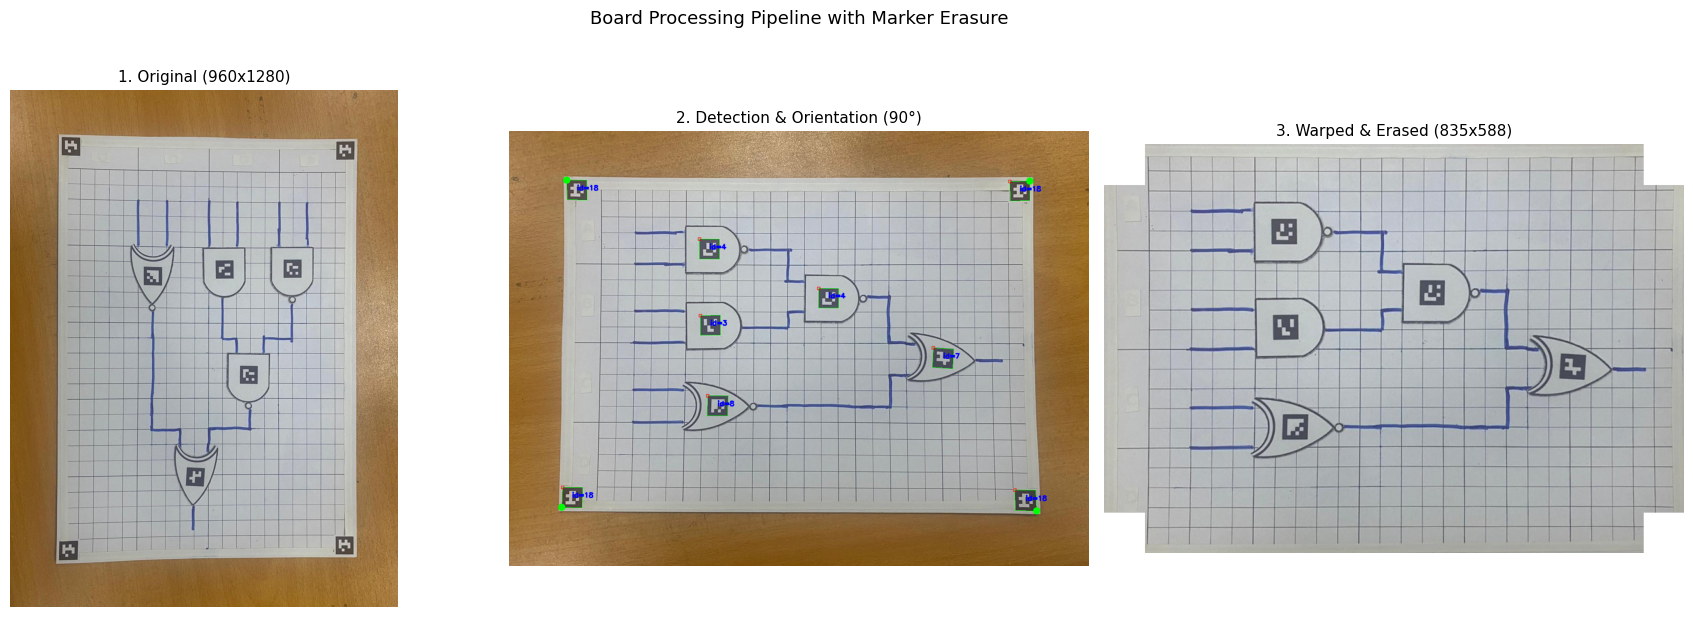

── Scanning for all logic gates ──────────────────────────────────
  XNOR   gate | ID=8 | center=(274,406) | bbox=(209,363,344,451)
  NAND   gate | ID=4 | center=(259,125) | bbox=(214,82,329,170)
  XOR    gate | ID=7 | center=(674,320) | bbox=(614,277,744,365)
  AND    gate | ID=3 | center=(261,263) | bbox=(218,221,316,306)
  NAND   gate | ID=4 | center=(472,214) | bbox=(427,171,542,259)

── Scan complete ─────────────────────────────────────────────────
  Total gates detected : 5


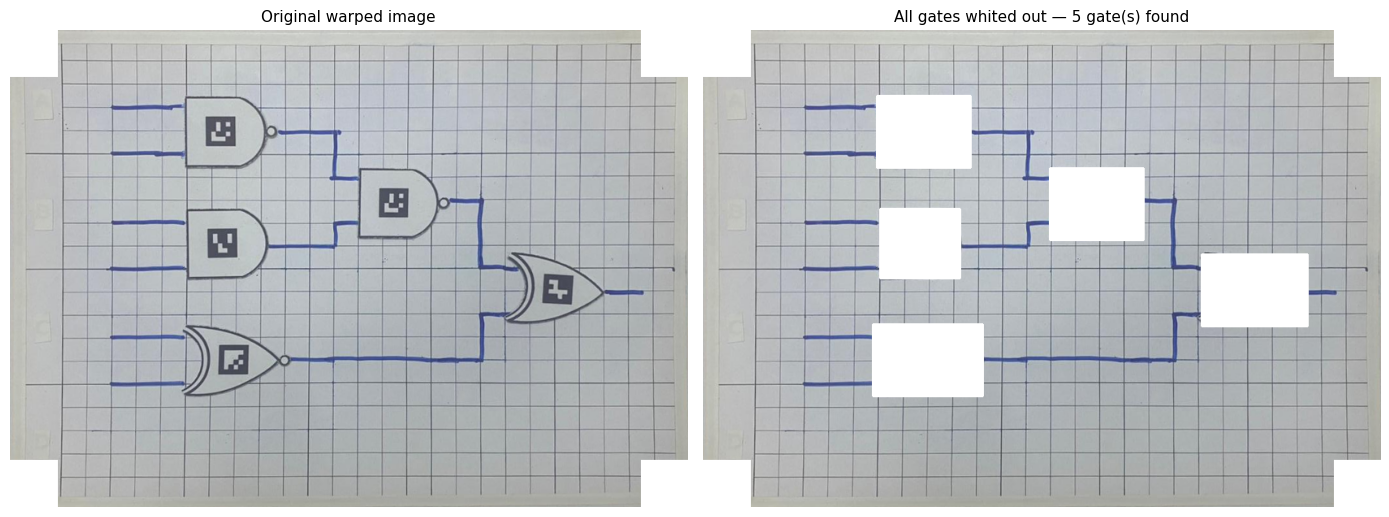

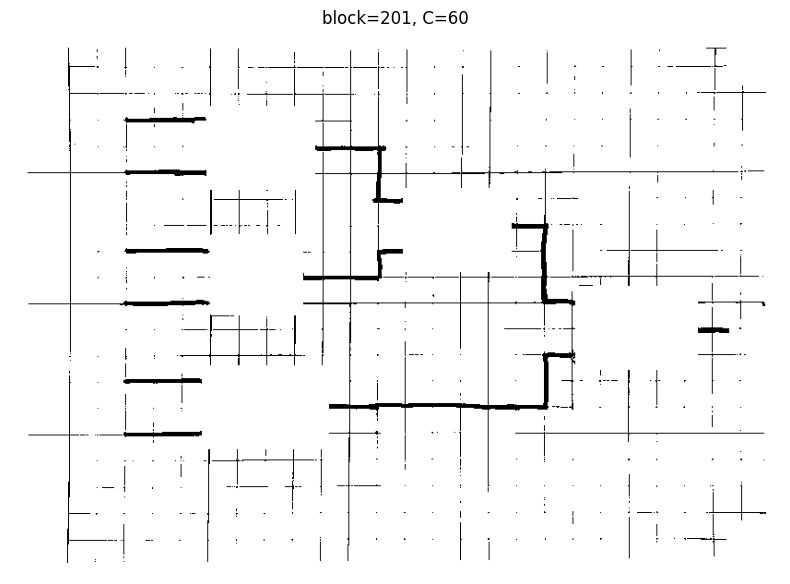

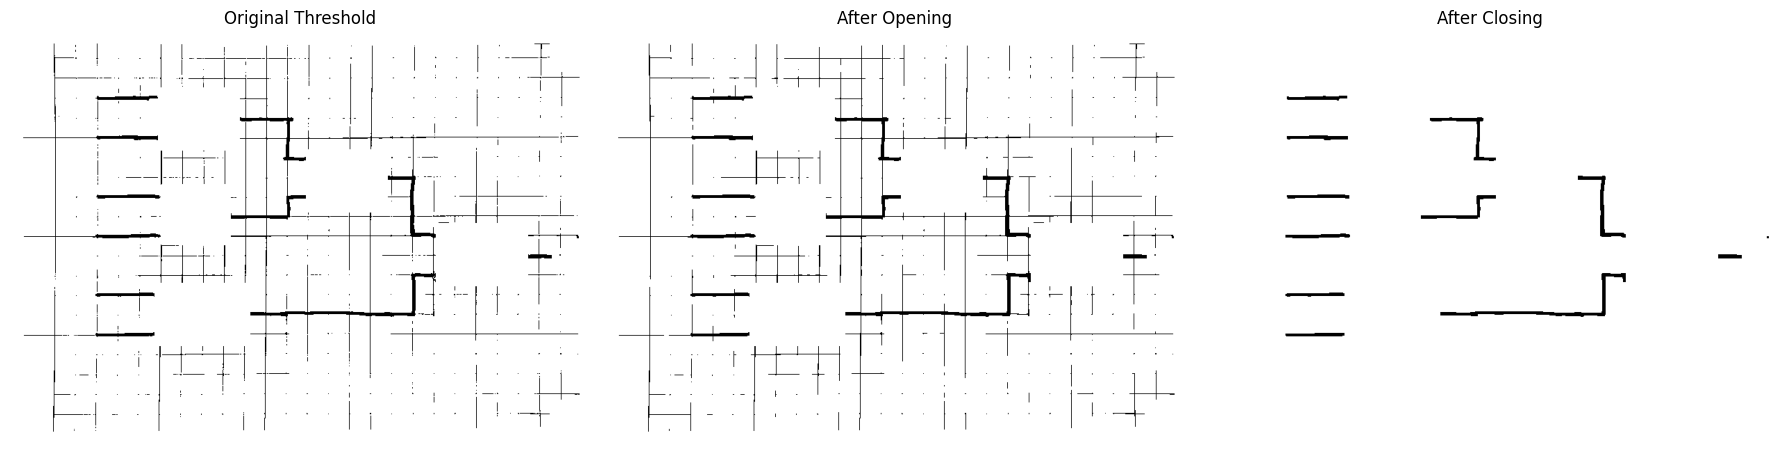

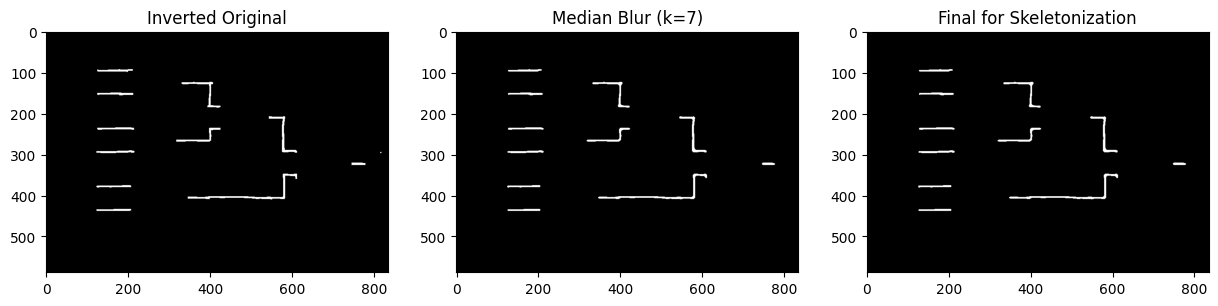

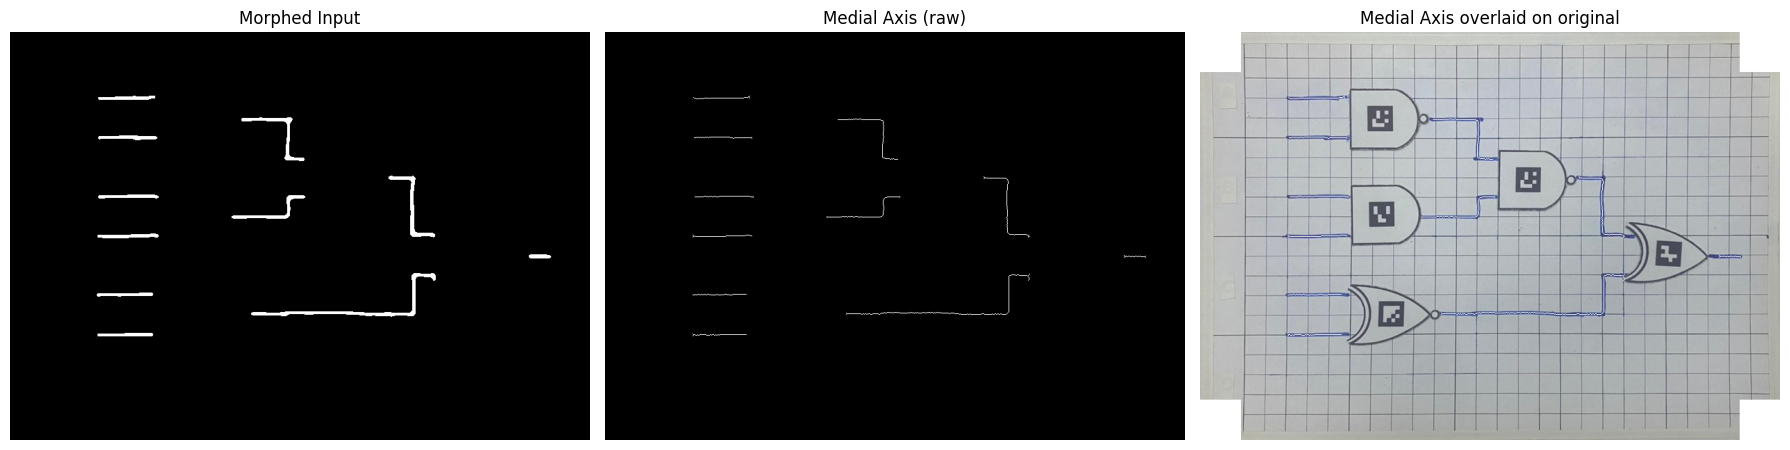

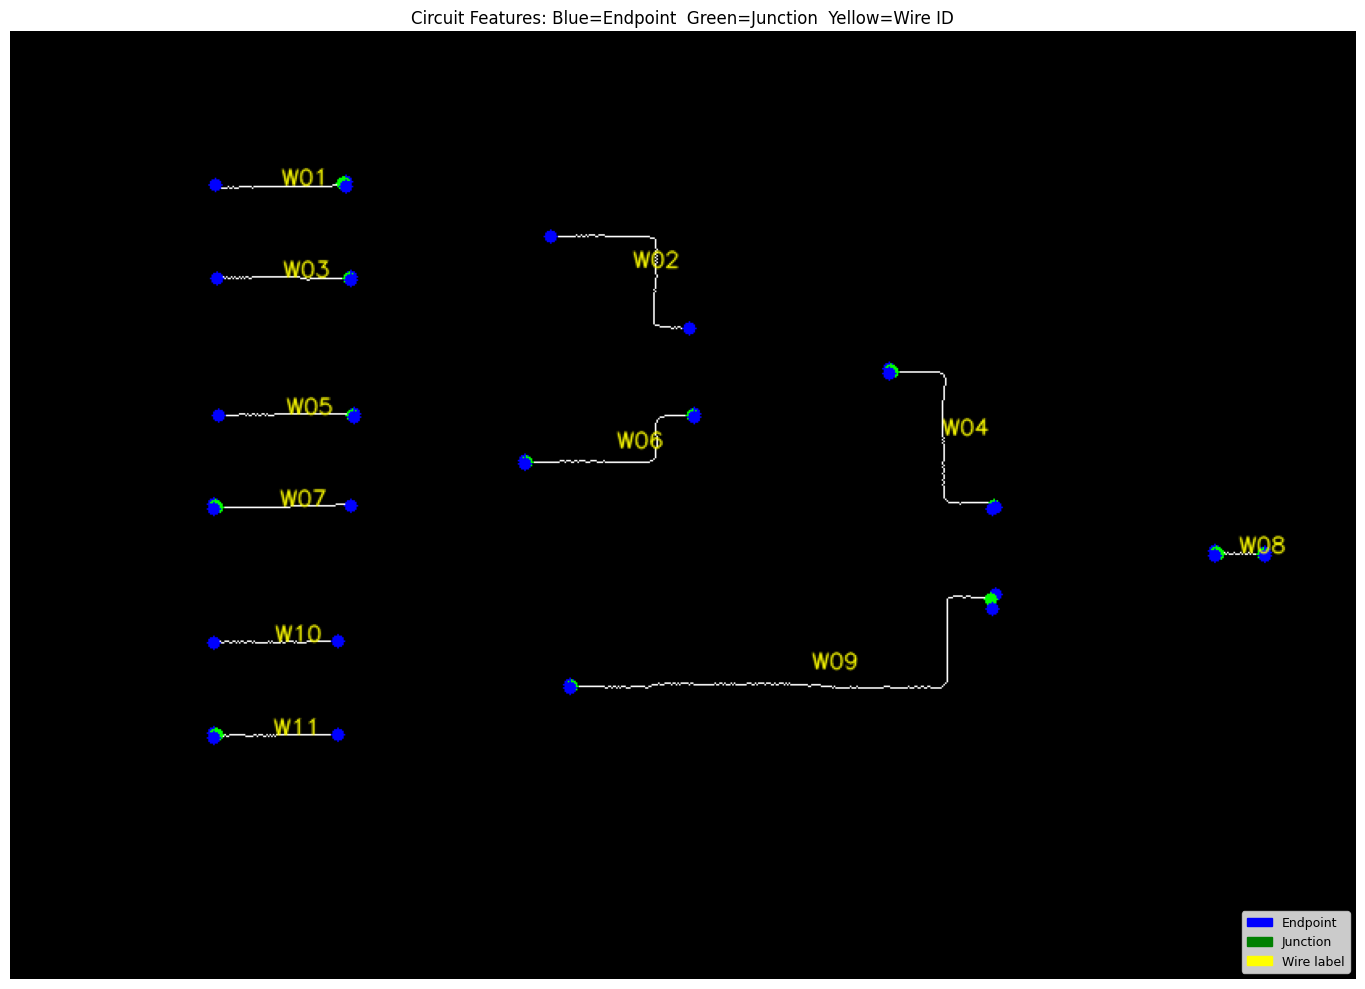

Wire01 --- EP01.1 (np.int64(208), np.int64(93)), EP01.2 (np.int64(127), np.int64(95)), EP01.3 (np.int64(208), np.int64(96)) --- JUNC01.1 (np.int64(206), np.int64(94)), JUNC01.2 (np.int64(207), np.int64(94)), JUNC01.3 (np.int64(207), np.int64(95))
Wire02 --- EP02.1 (np.int64(335), np.int64(127)), EP02.2 (np.int64(421), np.int64(184)) --- -
Wire03 --- EP03.1 (np.int64(211), np.int64(152)), EP03.2 (np.int64(128), np.int64(153)), EP03.3 (np.int64(211), np.int64(154)) --- JUNC03.1 (np.int64(210), np.int64(153))
Wire04 --- EP04.1 (np.int64(545), np.int64(209)), EP04.2 (np.int64(545), np.int64(212)), EP04.3 (np.int64(611), np.int64(295)), EP04.4 (np.int64(609), np.int64(296)) --- JUNC04.1 (np.int64(546), np.int64(210)), JUNC04.2 (np.int64(546), np.int64(211)), JUNC04.3 (np.int64(547), np.int64(211)), JUNC04.4 (np.int64(610), np.int64(294))
Wire05 --- EP05.1 (np.int64(213), np.int64(237)), EP05.2 (np.int64(129), np.int64(238)), EP05.3 (np.int64(213), np.int64(239)) --- JUNC05.1 (np.int64(212),

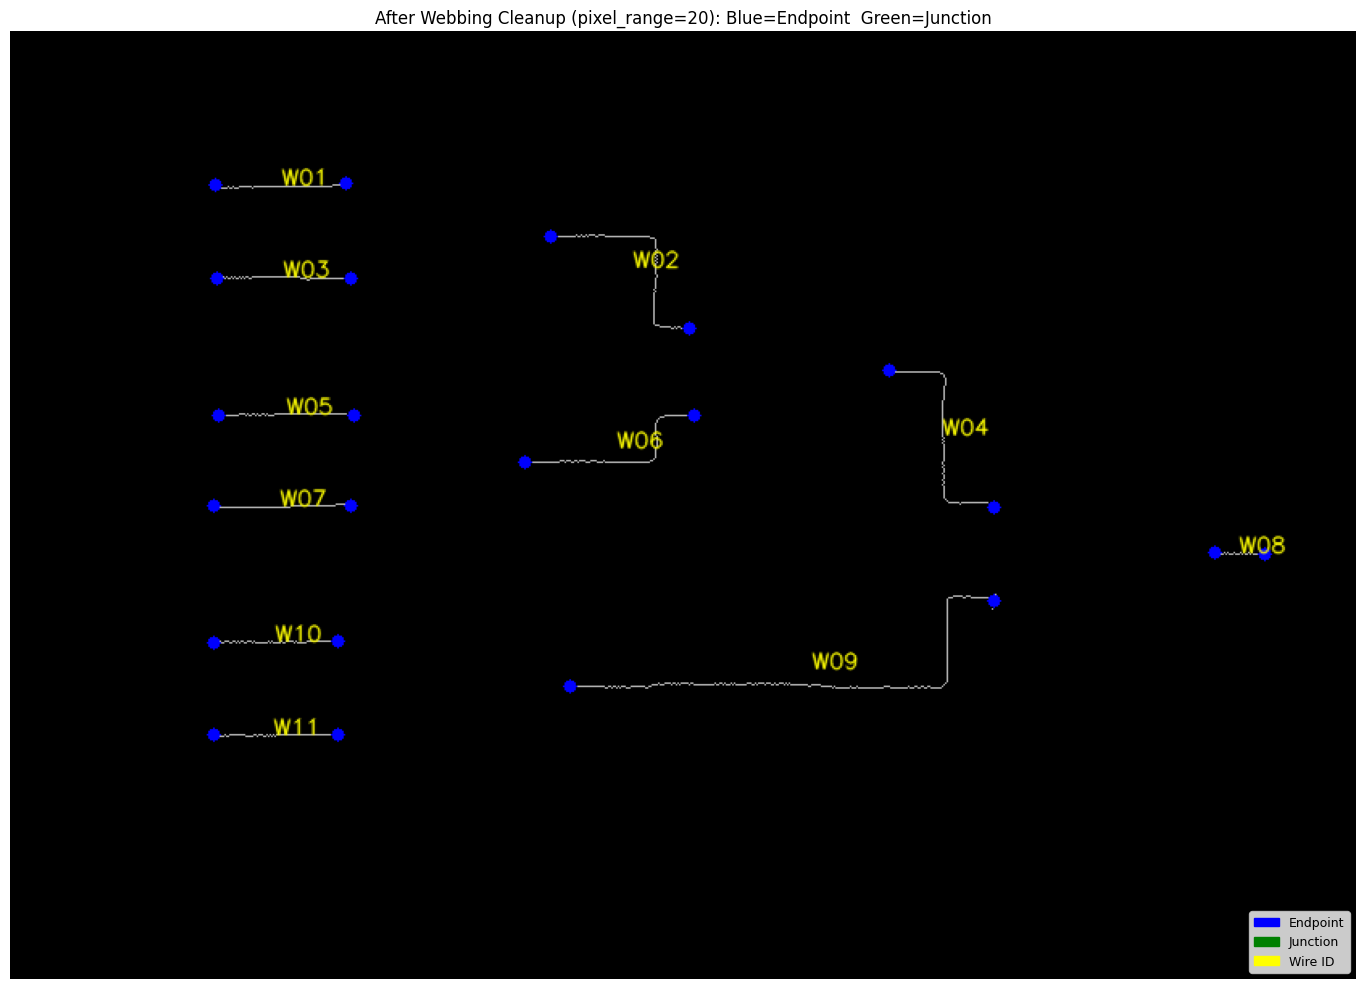

Wire01 --- EP01.1 (np.int64(127), np.int64(95)), EP01.2 (208, 94) --- -
Wire02 --- EP02.1 (np.int64(335), np.int64(127)), EP02.2 (np.int64(421), np.int64(184)) --- -
Wire03 --- EP03.1 (np.int64(128), np.int64(153)), EP03.2 (211, 153) --- -
Wire04 --- EP04.1 (545, 210), EP04.2 (610, 295) --- -
Wire05 --- EP05.1 (np.int64(129), np.int64(238)), EP05.2 (213, 238) --- -
Wire06 --- EP06.1 (424, 238), EP06.2 (319, 267) --- -
Wire07 --- EP07.1 (np.int64(211), np.int64(294)), EP07.2 (126, 294) --- -
Wire08 --- EP08.1 (747, 323), EP08.2 (778, 324) --- -
Wire09 --- EP09.1 (610, 353), EP09.2 (347, 406) --- -
Wire10 --- EP10.1 (np.int64(203), np.int64(378)), EP10.2 (np.int64(126), np.int64(379)) --- -
Wire11 --- EP11.1 (np.int64(203), np.int64(436)), EP11.2 (126, 436) --- -


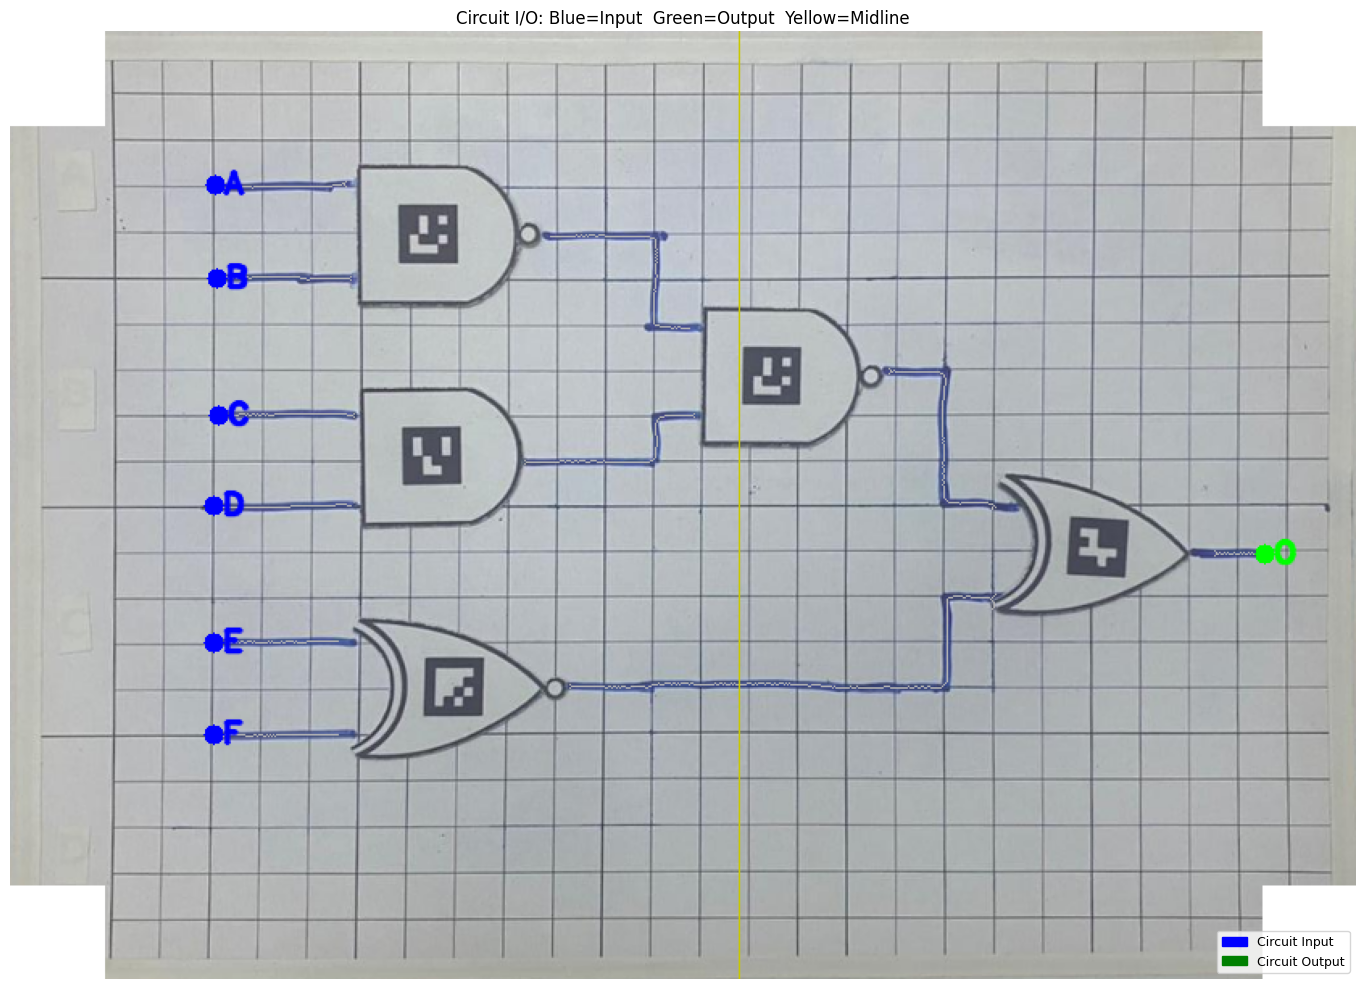

── Circuit Inputs ────────────────────────────────────────────────
  A → Wire01 at (np.int64(127), np.int64(95))
  B → Wire03 at (np.int64(128), np.int64(153))
  C → Wire05 at (np.int64(129), np.int64(238))
  D → Wire07 at (126, 294)
  E → Wire10 at (np.int64(126), np.int64(379))
  F → Wire11 at (126, 436)
── Circuit Output ────────────────────────────────────────────────
  O → Wire08 at (778, 324)
── Gate Port Assignments ─────────────────────────────────────────
  XNOR   | in1→W10 in2→W11 out→W09 
  NAND   | in1→W01 in2→W03 out→W02 
  XOR    | in1→W04 in2→W09 out→W08 
  AND    | in1→W05 in2→W07 out→W06 
  NAND   | in1→W02 in2→W06 out→W04 

── Boolean Expression ────────────────────────────────────────────
  O = ((NOT ((NOT (A AND B)) AND (C AND D))) XOR (NOT (E XOR F)))


In [17]:
image_path = input("Enter image path: ").strip()
warped_image, homography, rotation = process_board_image(image_path, output_size=(835, 588))
board_working, all_detections = scan_all_gates(warped_image, show=True)
thresh = Final_threshold(board_working, block_size=201, C=60)
opened, closed = apply_morphology(thresh, k1=5, k2=3)
smoothed_lines = median_smoothing_pipeline(closed, ksize=7)
medial_skel = compute_medial_axis(smoothed_lines, warped_image=warped_image)
wire_data, labels = extract_circuit_features(medial_skel, warped_image=None)
new_wire_data = cleanup_webbing(wire_data, pixel_range=20, warped_image=None , skel_uint8=medial_skel)
inputs, outputs = identify_circuit_io(new_wire_data, all_detections, warped_image=warped_image, skel_uint8=medial_skel, gate_margin=20)
expression = build_boolean_expression(new_wire_data, all_detections, inputs, outputs, port_margin=20)